## 분석 목차
1. 타겟변수 분포 — 디페깅 발생 현황
2. 디페깅 발생 타임라인
3. 클래스 불균형 확인
4. 변수 분포 특성 — Skewness (왜도)
5. 타깃과의 상관분석 (Point-Biserial)
6. 그룹별 분포 비교 — Boxplot & Mann-Whitney U 검정
7. 변수 간 상관관계 히트맵
8. Event Study — 디페깅 전후 변수 평균 추이
9. USDC vs DAI 비교 분석


## 0. 환경 설정


In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Windows 기준 Malgun Gothic)
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

import os
from pathlib import Path

# ── 경로 설정 ──────────────────────────────────────────────────────────────
BASE_DIR = Path('../data/processed')   # 전처리된 코인 데이터
ML_DIR   = Path('../data/ml')          # ML용 X/Y 파일
OUT_DIR  = Path('../outputs/eda')      # 그래프 저장 경로
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 분석 기간 설정 ─────────────────────────────────────────────────────────
START_DATE = '2021-01-01'  # ML 학습 시작 시점과 동일하게 맞춤

# ── 주요 이벤트 (수직선 표시용) ────────────────────────────────────────────
EVENTS = {
    'LUNA 붕괴\n(2022-05)': '2022-05-09',
    'FTX 파산\n(2022-11)' : '2022-11-08',
    'SVB 파산\n(2023-03)' : '2023-03-10',
}

# ── 분석 코인 목록 ─────────────────────────────────────────────────────────
COINS = ['USDC', 'DAI']
COIN_COLORS = {'USDC': '#5B9BD5', 'DAI': '#ED7D31'}

print('환경 설정 완료')
print(f'분석 기간: {START_DATE} ~ 2026-03-25')
print(f'분석 코인: {COINS}')


환경 설정 완료
분석 기간: 2021-01-01 ~ 2026-03-25
분석 코인: ['USDC', 'DAI']


In [2]:
# ── 데이터 로딩 및 depeg 재계산 ──────────────────────────────────────────
# df_usdc.csv / df_dai.csv 를 불러온 뒤 2021년 이후로 필터링
# 임계값은 rolling(30).sum() 기반으로 직접 재계산
# (저장된 depeg 컬럼이 있어도 여기서 명시적으로 다시 계산해 EDA 로직을 투명하게 유지)

dfs = {}  # {coin: DataFrame} 딕셔너리

for coin in COINS:
    df = pd.read_csv(BASE_DIR / f'df_{coin.lower()}.csv', parse_dates=['Date'])

    # 2021년 이후 데이터만 사용 (ML 학습 기간과 동일)
    df = df[df['Date'] >= START_DATE].reset_index(drop=True)

    # ── Kaiko 동적 임계값 계산 ────────────────────────────────────────────
    # V_monthly: 30일 롤링 합계 거래량
    # 거래량이 많을수록 V_monthly가 커지고 → 10/V^(1/3) 이 작아져 → 임계 범위가 좁아짐
    df['V_monthly'] = df[f'volume_{coin}'].rolling(30).sum()
    df['ThreshD']   = 1 - 10 / (df['V_monthly'] ** (1/3))  # 하한 임계값
    df['ThreshU']   = 1 + 10 / (df['V_monthly'] ** (1/3))  # 상한 임계값

    # ── 디페깅 레이블 생성 ────────────────────────────────────────────────
    # intraday low가 하한 이하 OR high가 상한 이상이면 depeg=1
    df['depeg'] = (
        (df[f'low_{coin}']  <= df['ThreshD']) |
        (df[f'high_{coin}'] >= df['ThreshU'])
    ).astype(int)

    dfs[coin] = df
    n1 = df['depeg'].sum()
    n0 = len(df) - n1
    print(f'{coin}: 전체 {len(df)}행 | 디페깅(1) {n1}건({n1/len(df)*100:.1f}%) | 정상(0) {n0}건({n0/len(df)*100:.1f}%)')


USDC: 전체 1910행 | 디페깅(1) 168건(8.8%) | 정상(0) 1742건(91.2%)
DAI: 전체 1910행 | 디페깅(1) 107건(5.6%) | 정상(0) 1803건(94.4%)


---
## 1. 타깃변수 분포 — 디페깅 발생 현황

**확인 목적:**
- USDC와 DAI 각각의 디페깅 발생 비율이 어느 수준인지 파악
- 코인 간 발생률 차이를 비교해 두 코인의 안정성 차이 확인
- 클래스 불균형의 심각도를 직관적으로 파악 (이후 SMOTE 적용 근거)


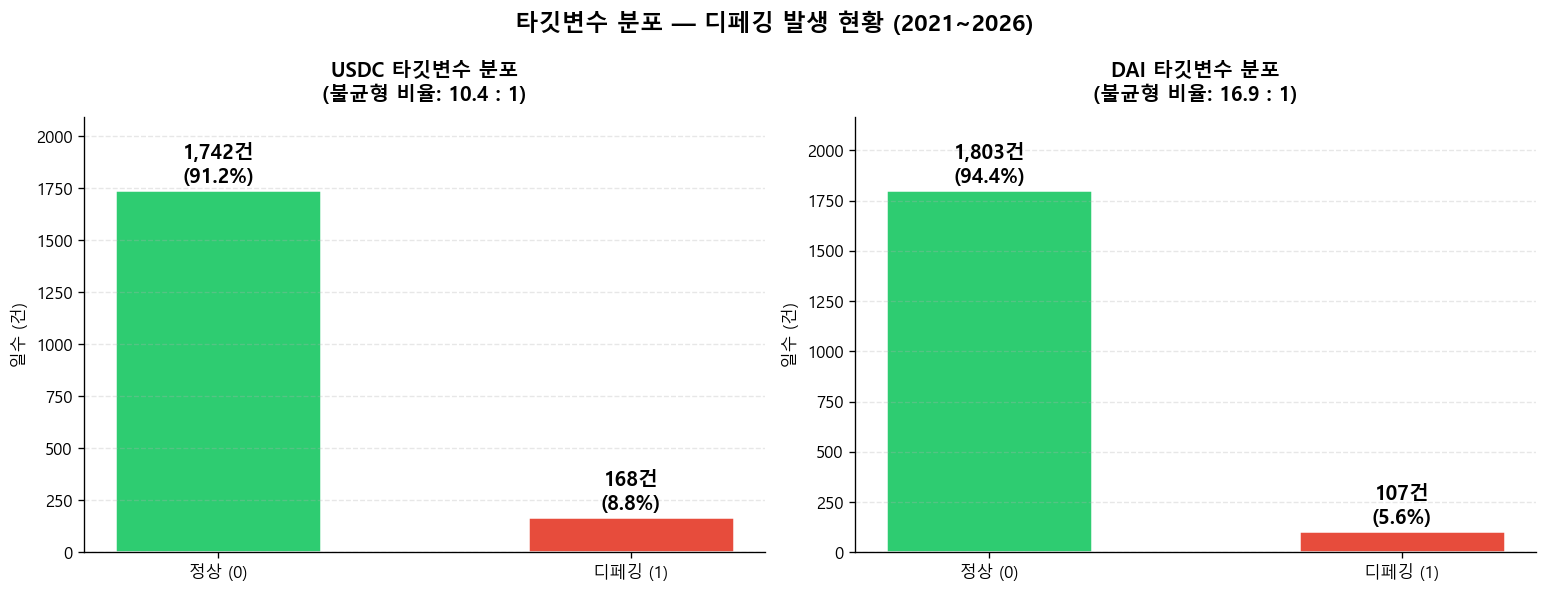

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, coin in zip(axes, COINS):
    df   = dfs[coin]
    n1   = df['depeg'].sum()
    n0   = len(df) - n1
    pct1 = n1 / len(df) * 100
    pct0 = n0 / len(df) * 100

    # 정상(0) / 디페깅(1) 두 막대
    bars = ax.bar(['정상 (0)', '디페깅 (1)'], [n0, n1],
                  color=['#2ECC71', '#E74C3C'],
                  width=0.5, edgecolor='white', linewidth=1.5)

    # 각 막대 위에 건수 및 비율 표시
    for bar, val, pct in zip(bars, [n0, n1], [pct0, pct1]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 10,
                f'{val:,}건\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.set_title(f'{coin} 타깃변수 분포\n(불균형 비율: {n0/n1:.1f} : 1)',
                 fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('일수 (건)', fontsize=10)
    ax.set_ylim(0, max(n0, n1) * 1.2)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('타깃변수 분포 — 디페깅 발생 현황 (2021~2026)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'eda_01_target_dist.png', bbox_inches='tight')
plt.show()


---
## 2. 디페깅 발생 타임라인

**확인 목적:**
- 디페깅이 특정 시기에 집중되는지, 아니면 무작위로 발생하는지 파악
- 주요 거시경제 충격(LUNA, FTX, SVB)과 디페깅 발생이 일치하는지 시각적으로 확인
- 동적 임계값(초록 음영)이 시간에 따라 어떻게 변하는지 확인
  - 거래량이 적을 때(초기): 임계 범위 넓음
  - 거래량이 많을 때(후기): 임계 범위 좁음


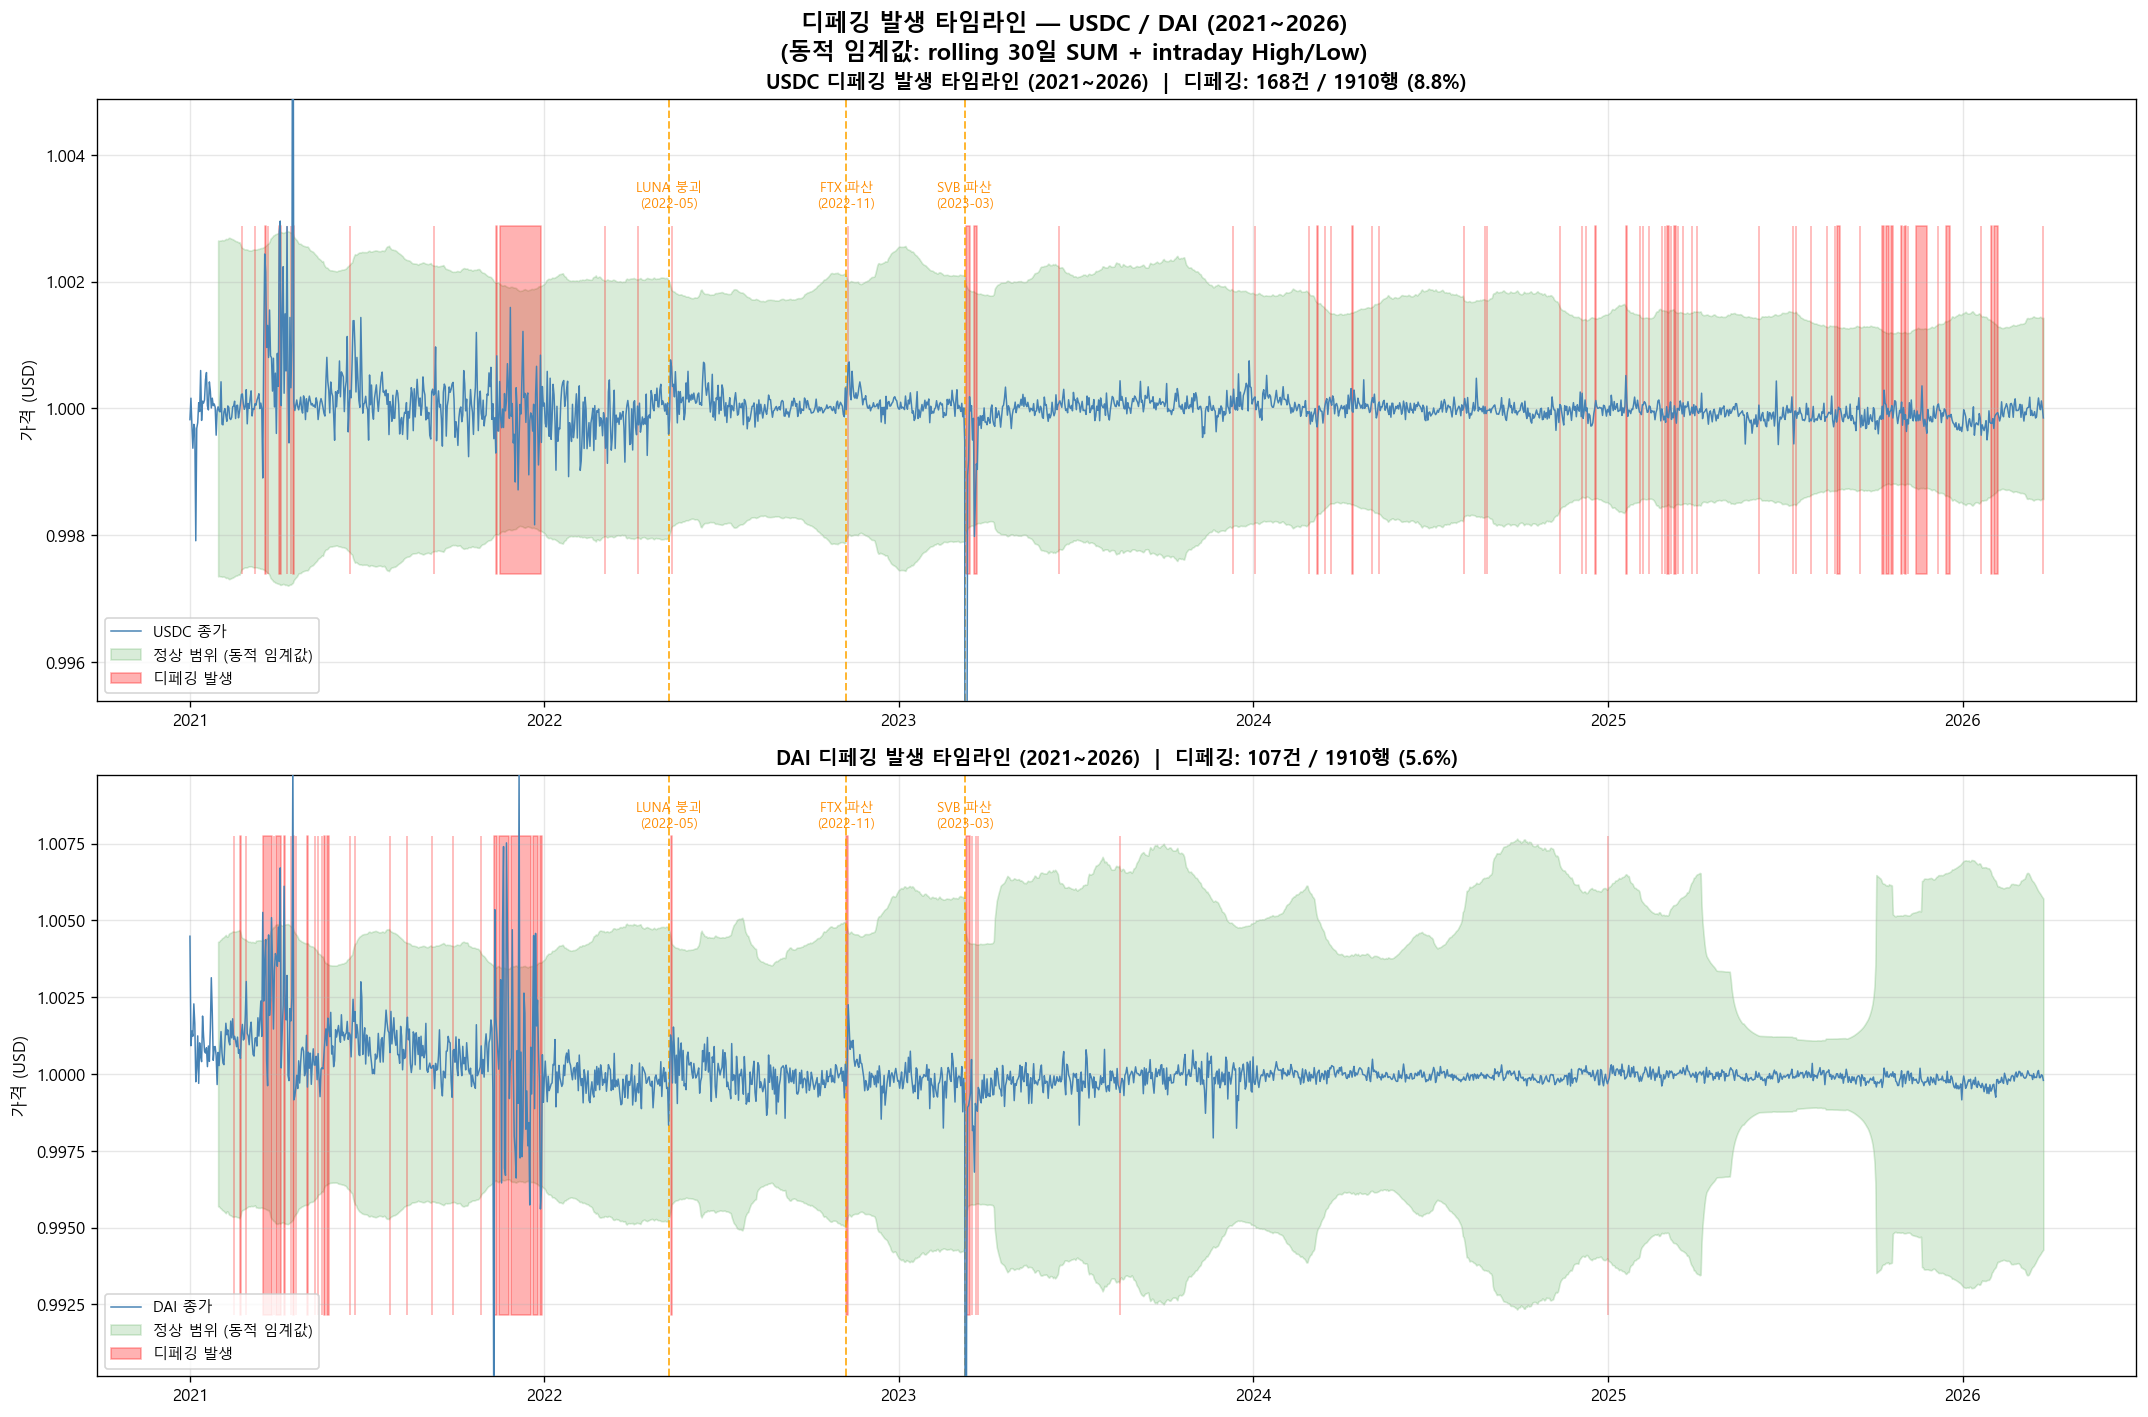

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

for ax, coin in zip(axes, COINS):
    df    = dfs[coin]
    close = df[f'close_{coin}']
    ymin  = close.quantile(0.001)
    ymax  = close.quantile(0.999)

    # ── 종가 라인 ────────────────────────────────────────────────────────
    ax.plot(df['Date'], close,
            color='steelblue', linewidth=0.9, label=f'{coin} 종가', zorder=3)

    # ── 동적 임계값 밴드 (초록 음영) ─────────────────────────────────────
    # ThreshD ~ ThreshU 사이가 '정상 범위'
    ax.fill_between(df['Date'], df['ThreshD'], df['ThreshU'],
                    alpha=0.15, color='green', label='정상 범위 (동적 임계값)')

    # ── 디페깅 발생 구간 (빨간 음영) ─────────────────────────────────────
    # depeg=1인 날짜에 배경을 빨갛게 칠해 발생 시점을 강조
    ax.fill_between(df['Date'], ymin, ymax,
                    where=df['depeg'] == 1,
                    alpha=0.30, color='red', label='디페깅 발생')

    # ── 주요 이벤트 수직선 ────────────────────────────────────────────────
    for label, date_str in EVENTS.items():
        ev = pd.Timestamp(date_str)
        if df['Date'].min() <= ev <= df['Date'].max():
            ax.axvline(ev, color='orange', linestyle='--', linewidth=1.2, alpha=0.8)
            ax.text(ev, ymax * 1.0003, label,
                    fontsize=8, ha='center', color='darkorange')

    n_dep = df['depeg'].sum()
    ax.set_title(
        f'{coin} 디페깅 발생 타임라인 (2021~2026)  |  '
        f'디페깅: {n_dep}건 / {len(df)}행 ({n_dep/len(df)*100:.1f}%)',
        fontsize=12, fontweight='bold')
    ax.set_ylabel('가격 (USD)', fontsize=10)
    ax.legend(loc='lower left', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(ymin * 0.998, ymax * 1.002)

plt.suptitle('디페깅 발생 타임라인 — USDC / DAI (2021~2026)\n'
             '(동적 임계값: rolling 30일 SUM + intraday High/Low)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'eda_02_timeline.png', bbox_inches='tight')
plt.show()


---
## 3. 클래스 불균형 분석

**확인 목적:**
- 정상(0) vs 디페깅(1) 비율이 얼마나 불균형한지 수치로 파악
- 불균형 비율이 클수록 모델이 정상 클래스만 예측해도 높은 Accuracy가 나오는 문제 발생
  → 이를 해결하기 위해 **SMOTE(오버샘플링)** 적용 예정
- Accuracy 대신 **Precision-Recall AUC**, **F1-score**, **복합 스코어 C** 를 평가지표로 사용하는 근거


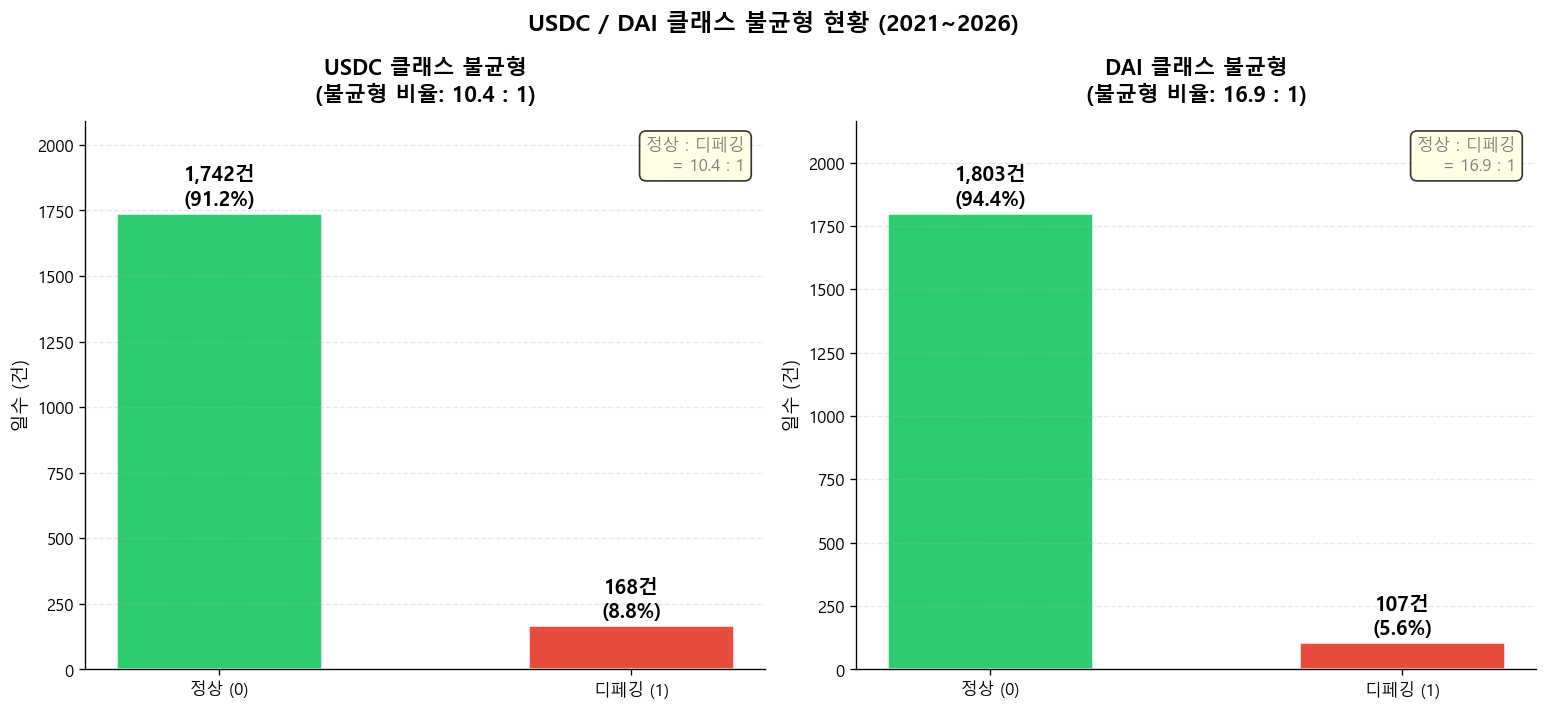

클래스 불균형 요약
USDC: 정상 1742건 | 디페깅 168건 | 비율 10.4:1 → SMOTE 적용 필요
DAI: 정상 1803건 | 디페깅 107건 | 비율 16.9:1 → SMOTE 적용 필요


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, coin in zip(axes, COINS):
    df    = dfs[coin]
    n1    = df['depeg'].sum()
    n0    = len(df) - n1
    total = len(df)
    ratio = n0 / n1  # 불균형 비율 (정상:디페깅)

    bars = ax.bar(['정상 (0)', '디페깅 (1)'], [n0, n1],
                  color=['#2ECC71', '#E74C3C'],
                  width=0.5, edgecolor='white', linewidth=1.5)

    # 건수 및 비율 레이블
    for bar, val, pct in zip(bars, [n0, n1], [n0/total*100, n1/total*100]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 10,
                f'{val:,}건\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.set_title(f'{coin} 클래스 불균형\n(불균형 비율: {ratio:.1f} : 1)',
                 fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel('일수 (건)', fontsize=11)
    ax.set_ylim(0, max(n0, n1) * 1.2)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

    # 불균형 비율 텍스트 박스
    ax.text(0.97, 0.97,
            f'정상 : 디페깅\n= {ratio:.1f} : 1',
            transform=ax.transAxes, ha='right', va='top', fontsize=10, color='gray',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))

plt.suptitle('USDC / DAI 클래스 불균형 현황 (2021~2026)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'eda_03_class_imbalance.png', bbox_inches='tight')
plt.show()

# 요약 출력
print('=' * 50)
print('클래스 불균형 요약')
print('=' * 50)
for coin in COINS:
    df  = dfs[coin]
    n1  = df['depeg'].sum()
    n0  = len(df) - n1
    print(f'{coin}: 정상 {n0}건 | 디페깅 {n1}건 | 비율 {n0/n1:.1f}:1 → SMOTE 적용 필요')


---
## 4. 변수 분포 특성 — Skewness (왜도)

**Skewness(왜도)란?**
- 분포가 좌우 대칭에서 얼마나 치우쳐 있는지 나타내는 통계량
- `|skew| < 1`: 대칭에 가까움
- `1 ≤ |skew| < 3`: 중간 비대칭
- `|skew| ≥ 3`: 강한 비대칭 — 극단적 이상값 존재 가능성 높음
- 양수(+): 오른쪽 꼬리가 길다 (극단적으로 큰 값이 간헐적으로 존재)
- 음수(-): 왼쪽 꼬리가 길다

**확인 목적:**
- Point-Biserial 상관 기준 상위 20개 피처의 왜도를 확인
- `|skew| ≥ 3` 인 변수는 극단값이 모델 학습을 왜곡할 수 있어 로그변환 등 전처리 필요
- 금융 데이터 특성상 거래량·변동성 지표는 보통 강한 오른쪽 꼬리를 가짐


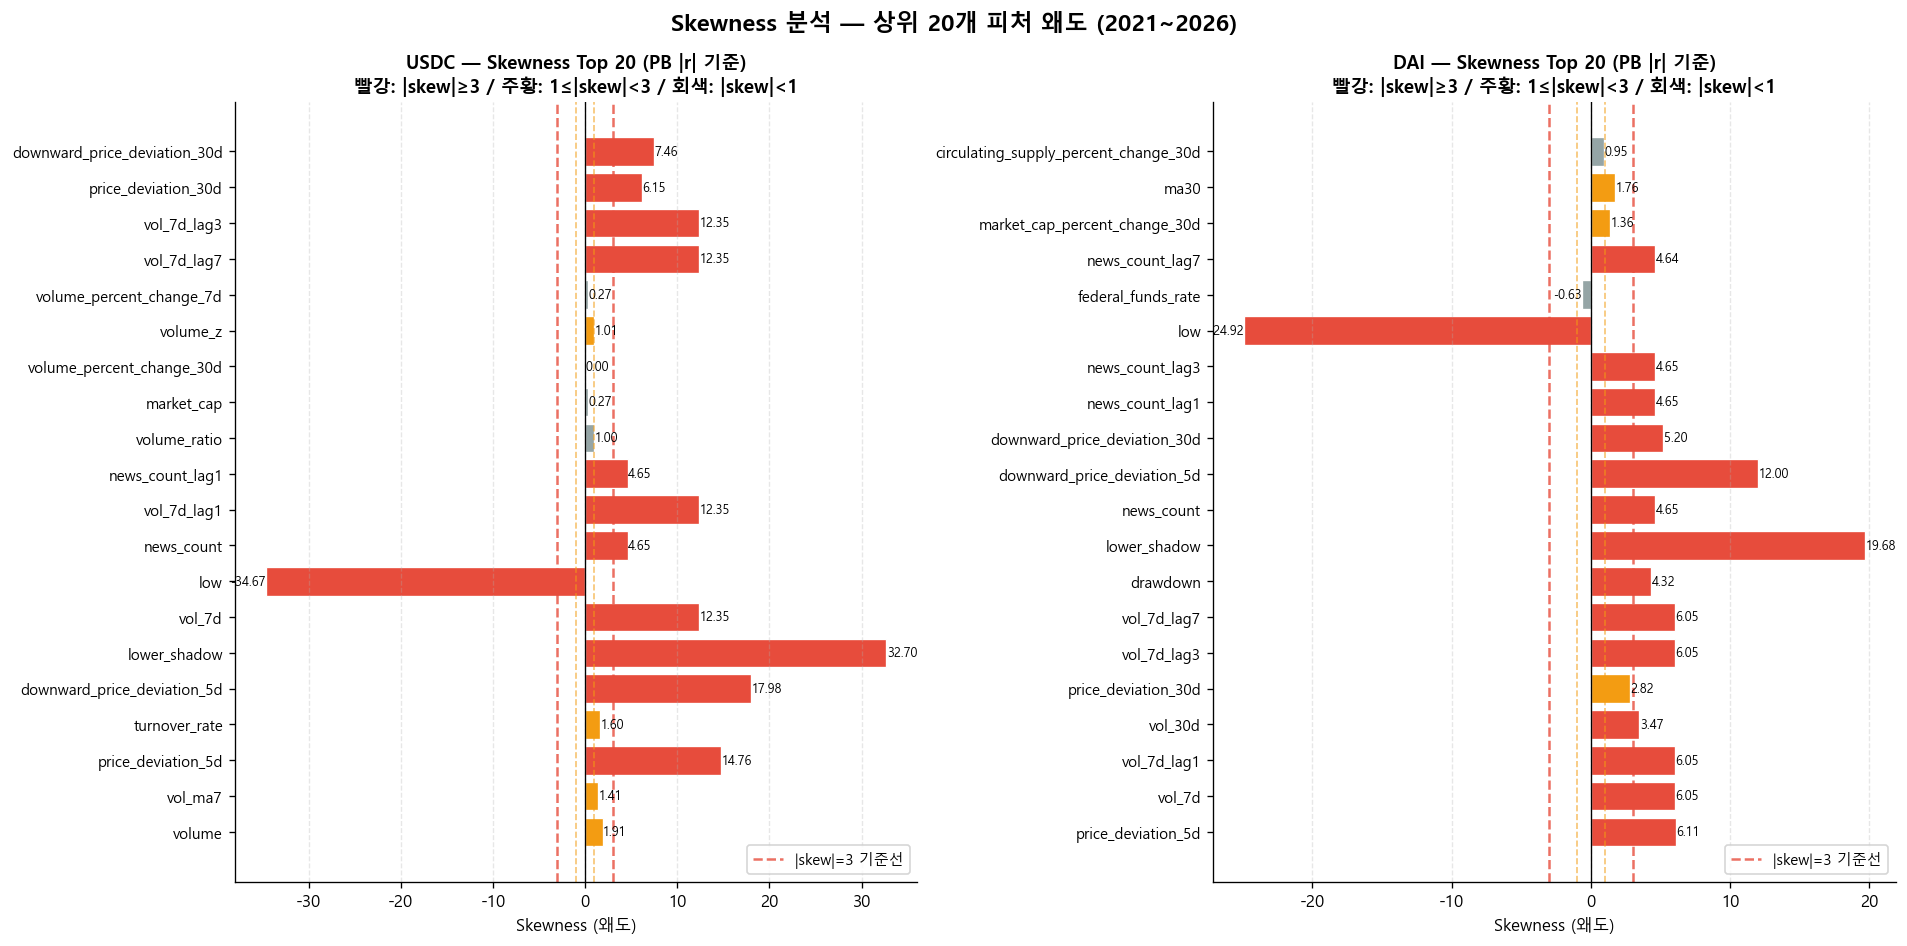


|skew| >= 3.0 인 변수 (강한 비대칭):
  USDC: 50개 → ['high_USDC', 'upper_shadow_USDC', 'high_low_spread_USDC', 'realized_vol_USDC', 'low_USDC'] ...
  DAI: 53개 → ['upper_shadow_DAI', 'high_DAI', 'high_low_spread_DAI', 'realized_vol_DAI', 'mcap_change_x_netflow_DAI'] ...


In [6]:
from scipy.stats import pointbiserialr

# ── 상위 20개 피처 선택 (Point-Biserial |r| 기준) ─────────────────────────
# depeg/thresh/V_monthly 관련 컬럼은 타깃 생성에 직접 사용되어 제외 (data leakage 방지)
SKEW_THRESHOLD = 3.0  # |skew| >= 3 이면 '강한 비대칭'으로 강조

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, coin in zip(axes, COINS):
    df = dfs[coin]

    # 수치형 컬럼에서 제외 키워드 포함 컬럼 제거
    num_cols  = df.select_dtypes(include=[np.number]).columns.tolist()
    excl_kw   = ['depeg', 'thresh', 'V_monthly', 'ThreshD', 'ThreshU']
    feat_cols = [c for c in num_cols
                 if not any(kw in c for kw in excl_kw)]

    # Point-Biserial 상관으로 상위 20개 피처 선택
    pb_scores = {}
    for col in feat_cols:
        valid = df[[col, 'depeg']].dropna()
        if len(valid) > 30 and valid[col].std() > 0:
            r, _ = pointbiserialr(valid['depeg'], valid[col])
            pb_scores[col] = abs(r)

    # 상위 20개 피처
    top20_cols = sorted(pb_scores, key=pb_scores.get, reverse=True)[:20]

    # 왜도 계산
    skews  = df[top20_cols].skew().values
    labels = [c.replace(f'_{coin}', '') for c in top20_cols]

    # 색상 구분:
    #   |skew| >= 3  → 빨강 (강한 비대칭, 주의 필요)
    #   1 <= |s| < 3 → 주황 (중간 비대칭)
    #   |skew| < 1   → 회색 (대칭에 가까움)
    bar_colors = [
        '#E74C3C' if abs(s) >= SKEW_THRESHOLD
        else ('#F39C12' if abs(s) >= 1 else '#95A5A6')
        for s in skews
    ]

    y_pos = np.arange(len(labels))
    ax.barh(y_pos, skews, color=bar_colors, edgecolor='white', linewidth=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)

    # 기준선: 0, ±1, ±3
    ax.axvline(0,               color='black', linewidth=0.8)
    ax.axvline( 1,              color='#F39C12', linewidth=1,   linestyle='--', alpha=0.6)
    ax.axvline(-1,              color='#F39C12', linewidth=1,   linestyle='--', alpha=0.6)
    ax.axvline( SKEW_THRESHOLD, color='#E74C3C', linewidth=1.5, linestyle='--', alpha=0.8,
                label=f'|skew|={SKEW_THRESHOLD:.0f} 기준선')
    ax.axvline(-SKEW_THRESHOLD, color='#E74C3C', linewidth=1.5, linestyle='--', alpha=0.8)

    # 각 막대 끝에 수치 표시
    for i, s in enumerate(skews):
        xpos = s + (0.05 if s >= 0 else -0.05)
        ha   = 'left' if s >= 0 else 'right'
        ax.text(xpos, i, f'{s:.2f}', va='center', ha=ha, fontsize=7.5)

    ax.set_title(
        f'{coin} — Skewness Top 20 (PB |r| 기준)\n'
        f'빨강: |skew|≥{SKEW_THRESHOLD:.0f} / 주황: 1≤|skew|<{SKEW_THRESHOLD:.0f} / 회색: |skew|<1',
        fontsize=11, fontweight='bold')
    ax.set_xlabel('Skewness (왜도)', fontsize=10)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Skewness 분석 — 상위 20개 피처 왜도 (2021~2026)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'eda_04_skewness.png', bbox_inches='tight')
plt.show()

# 강한 비대칭 변수 요약 출력
print(f'\n|skew| >= {SKEW_THRESHOLD} 인 변수 (강한 비대칭):')
for coin in COINS:
    df        = dfs[coin]
    num_cols  = df.select_dtypes(include=[np.number]).columns.tolist()
    excl_kw   = ['depeg', 'thresh', 'V_monthly', 'ThreshD', 'ThreshU']
    feat_cols = [c for c in num_cols if not any(kw in c for kw in excl_kw)]
    skew_all  = df[feat_cols].skew()
    high_skew = skew_all[skew_all.abs() >= SKEW_THRESHOLD].sort_values(key=abs, ascending=False)
    print(f'  {coin}: {len(high_skew)}개 → {list(high_skew.index[:5])} ...')


---
## 5. 타깃과의 상관분석 (Point-Biserial)

**Point-Biserial 상관계수란?**
- 연속형 변수와 이진 변수(0/1) 간의 상관관계를 측정
- Pearson 상관계수의 특수한 경우로, 타깃이 이진 분류일 때 적합
- 범위: -1 ~ +1 / |r| 클수록 타깃과 선형 관계가 강함

**확인 목적:**
- 어떤 변수가 디페깅(Y=1)과 강하게 연관되는지 파악
- lag 변수의 상관이 높으면 선행 신호가 존재 → 조기 경보에 유리


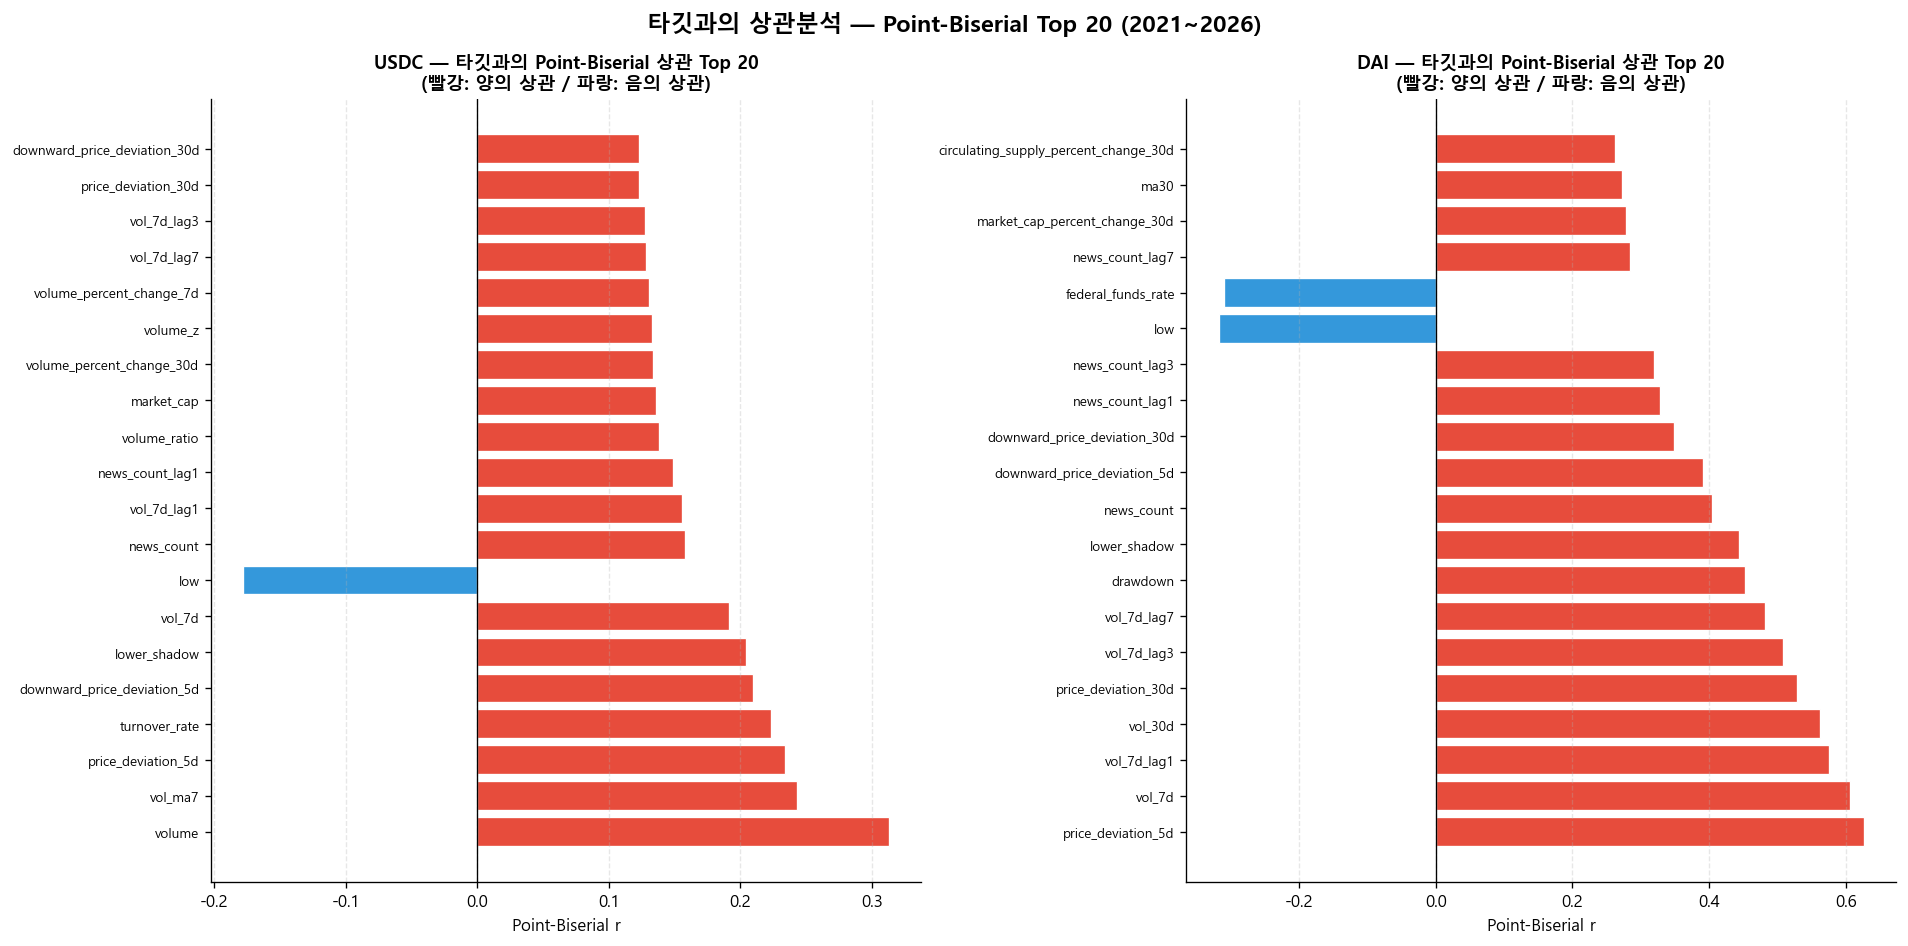

In [7]:
from scipy.stats import pointbiserialr

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, coin in zip(axes, COINS):
    df = dfs[coin]

    # 수치형 컬럼만 선택, depeg/thresh/V_monthly 관련 컬럼 제외
    num_cols  = df.select_dtypes(include=[np.number]).columns.tolist()
    excl_kw   = ['depeg', 'thresh', 'V_monthly', 'ThreshD', 'ThreshU']
    feat_cols = [c for c in num_cols
                 if not any(kw in c for kw in excl_kw)]

    # Point-Biserial 상관계수 계산
    pb_scores = {}
    for col in feat_cols:
        valid = df[[col, 'depeg']].dropna()
        if len(valid) > 30 and valid[col].std() > 0:
            r, _ = pointbiserialr(valid['depeg'], valid[col])
            pb_scores[col] = r

    # 절댓값 기준 상위 20개 선택
    top20 = sorted(pb_scores, key=lambda x: abs(pb_scores[x]), reverse=True)[:20]
    scores = [pb_scores[c] for c in top20]
    labels = [c.replace(f'_{coin}', '') for c in top20]

    # 색상: 양의 상관(빨강), 음의 상관(파랑)
    bar_colors = ['#E74C3C' if s > 0 else '#3498DB' for s in scores]

    y_pos = np.arange(len(top20))
    ax.barh(y_pos, scores, color=bar_colors, edgecolor='white', linewidth=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{coin} — 타깃과의 Point-Biserial 상관 Top 20\n'
                 f'(빨강: 양의 상관 / 파랑: 음의 상관)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Point-Biserial r', fontsize=10)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('타깃과의 상관분석 — Point-Biserial Top 20 (2021~2026)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'eda_05_pb_corr.png', bbox_inches='tight')
plt.show()


---
## 6. 그룹별 분포 비교 — Boxplot & Mann-Whitney U 검정

**Mann-Whitney U 검정이란?**
- 두 그룹(정상 vs 디페깅)의 분포가 통계적으로 다른지 검정
- 정규분포를 가정하지 않는 비모수 검정 → 금융 데이터에 적합
- p-value < 0.05: 두 그룹의 분포가 유의미하게 다름 → 해당 변수가 디페깅 예측에 유용

**확인 목적:**
- 디페깅 발생일(Y=1)과 정상일(Y=0)에서 변수 분포가 실제로 다른지 통계적으로 검증


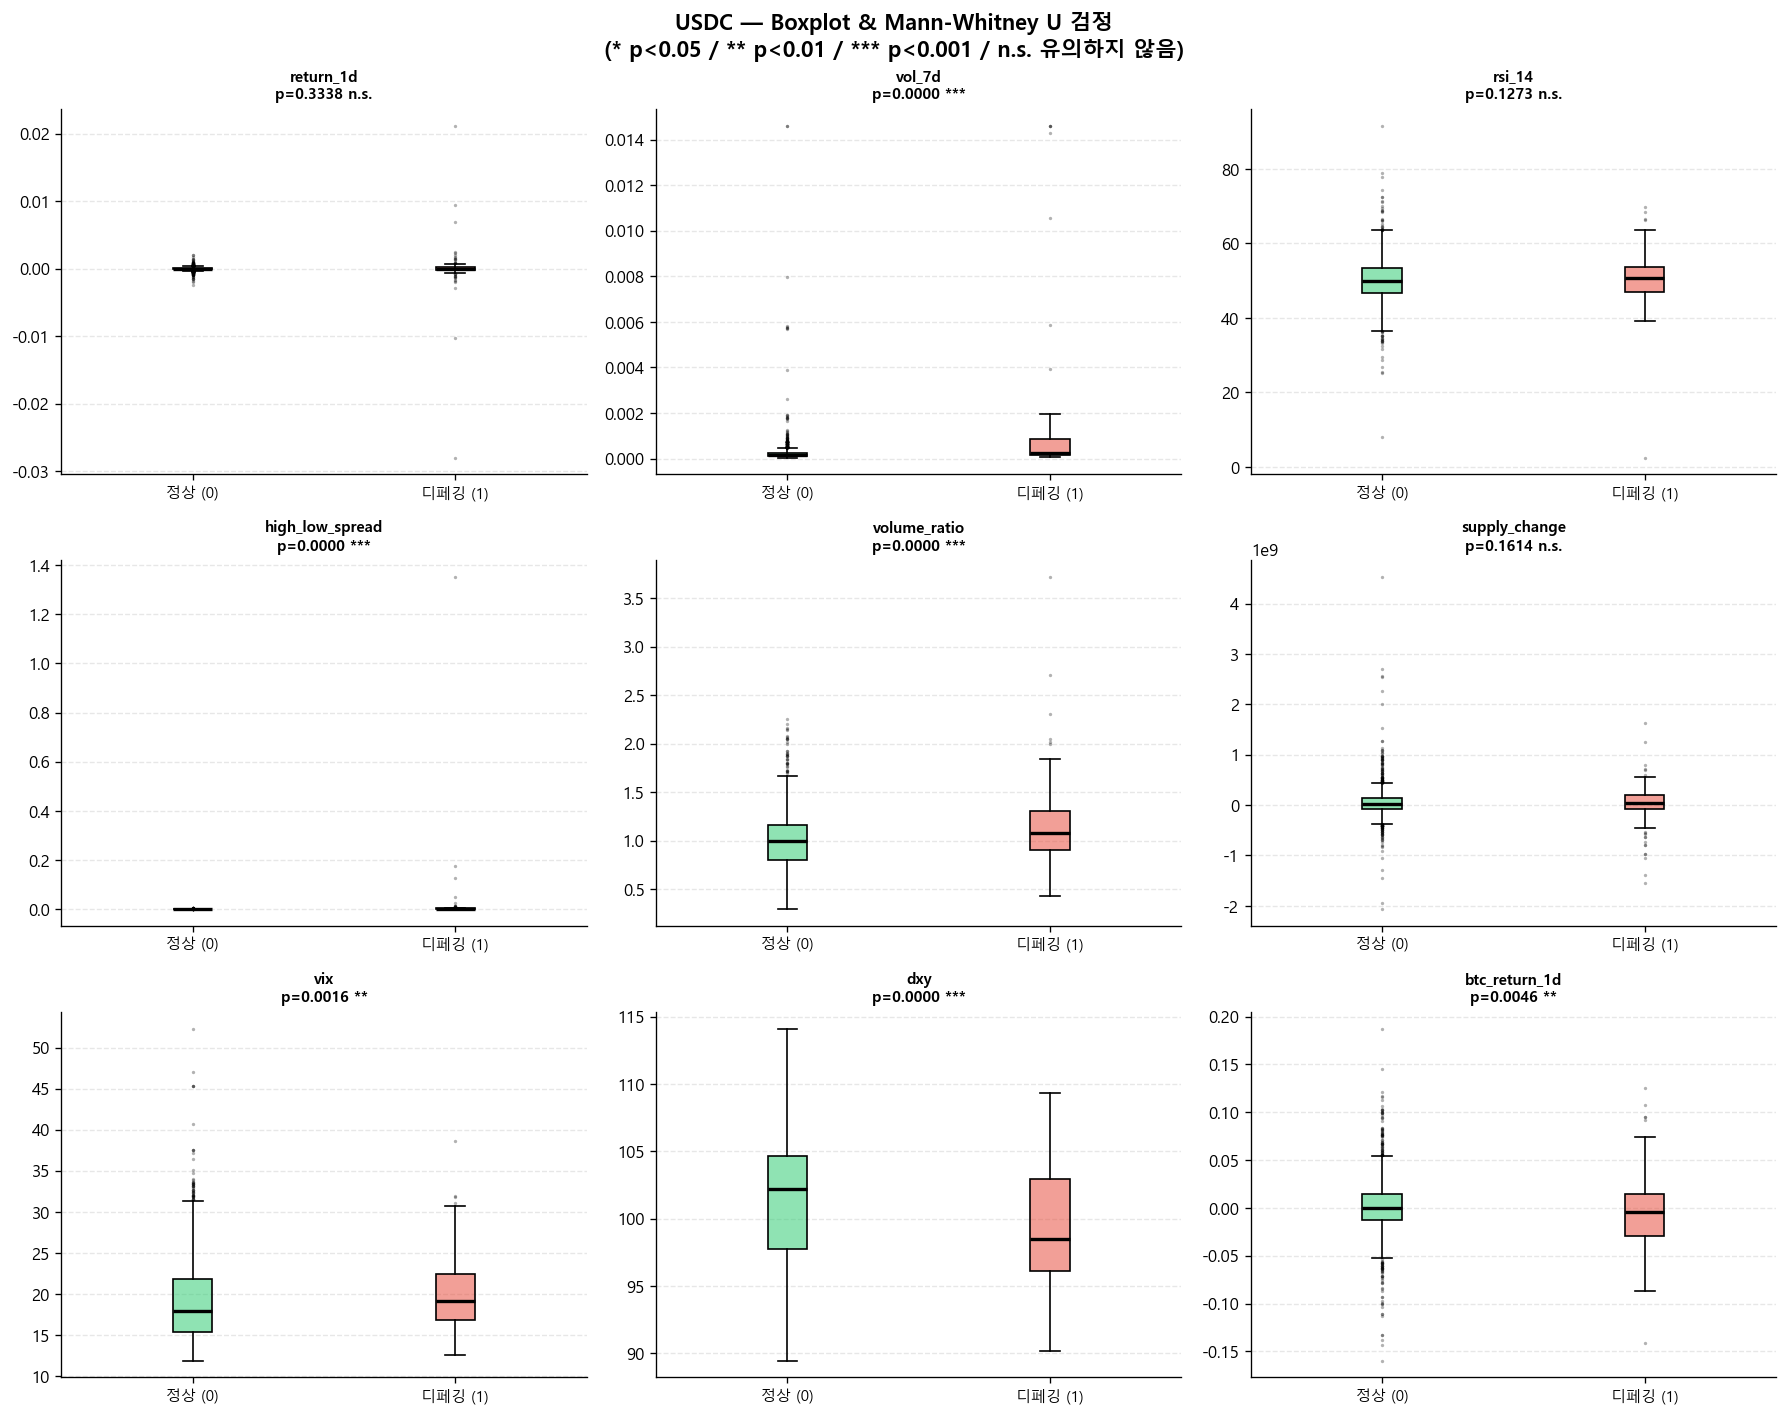

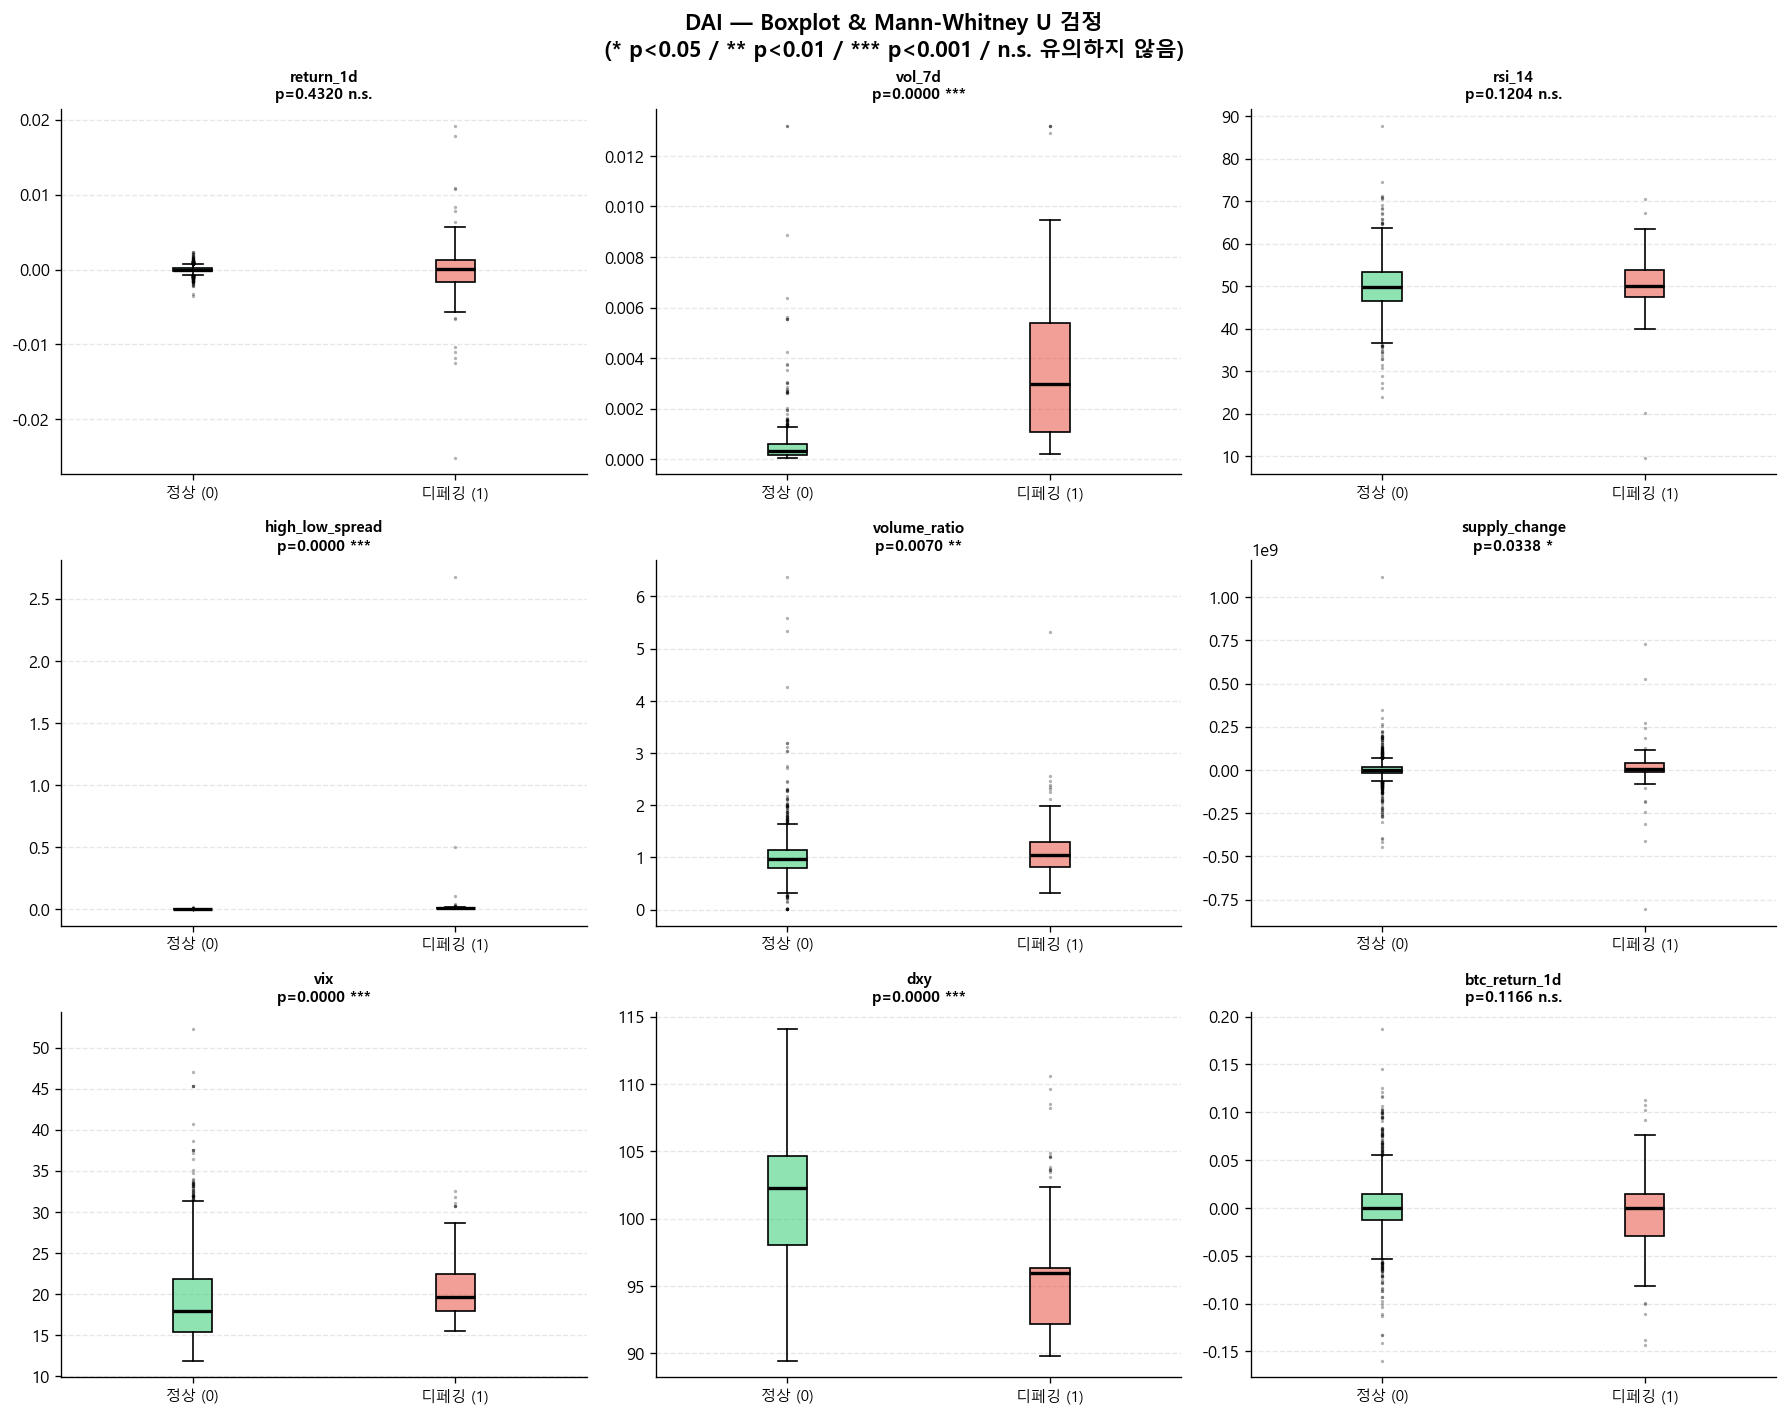

In [8]:
from scipy.stats import mannwhitneyu

# 분석할 대표 피처 목록 (코인별 피처는 _{coin} 접미사, 공통은 그대로)
MW_FEATURES = [
    'return_1d', 'vol_7d', 'rsi_14', 'high_low_spread',
    'volume_ratio', 'supply_change', 'vix', 'dxy', 'btc_return_1d',
]

for coin in COINS:
    df     = dfs[coin]
    normal = df[df['depeg'] == 0]  # 정상 그룹
    depeg  = df[df['depeg'] == 1]  # 디페깅 그룹

    # 실제 존재하는 컬럼만 필터링
    plot_cols, plot_labels = [], []
    for f in MW_FEATURES:
        col = f'{f}_{coin}' if f'{f}_{coin}' in df.columns else f
        if col in df.columns:
            plot_cols.append(col)
            plot_labels.append(f)

    n_cols = 3
    n_rows = (len(plot_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    axes = axes.flatten()

    for i, (col, label) in enumerate(zip(plot_cols, plot_labels)):
        ax = axes[i]
        g0 = normal[col].dropna()
        g1 = depeg[col].dropna()

        # Mann-Whitney U 검정 (양측 검정)
        stat, p = mannwhitneyu(g0, g1, alternative='two-sided')
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))

        # Boxplot: 정상(초록) vs 디페깅(빨강)
        bp = ax.boxplot([g0, g1],
                        patch_artist=True,
                        medianprops=dict(color='black', linewidth=2),
                        flierprops=dict(marker='.', markersize=2, alpha=0.3))
        bp['boxes'][0].set_facecolor('#2ECC7188')
        bp['boxes'][1].set_facecolor('#E74C3C88')

        ax.set_xticks([1, 2])
        ax.set_xticklabels(['정상 (0)', '디페깅 (1)'], fontsize=9)
        ax.set_title(f'{label}\np={p:.4f} {sig}', fontsize=9, fontweight='bold')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.spines[['top', 'right']].set_visible(False)

    for j in range(len(plot_cols), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(
        f'{coin} — Boxplot & Mann-Whitney U 검정\n'
        f'(* p<0.05 / ** p<0.01 / *** p<0.001 / n.s. 유의하지 않음)',
        fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'eda_06_boxplot_{coin.lower()}.png', bbox_inches='tight')
    plt.show()


---
## 7. 변수 간 상관관계 히트맵

**60개 변수를 그대로 그리면 너무 작아서 해석 불가 → 두 가지 방법 사용**

- **Method 1 (5×5):** 피처를 5개 카테고리로 묶어 카테고리 간 평균 |r| 계산
- **Method 2 (20×20):** Point-Biserial |r| 상위 20개 피처만 추출해 상호 상관 확인


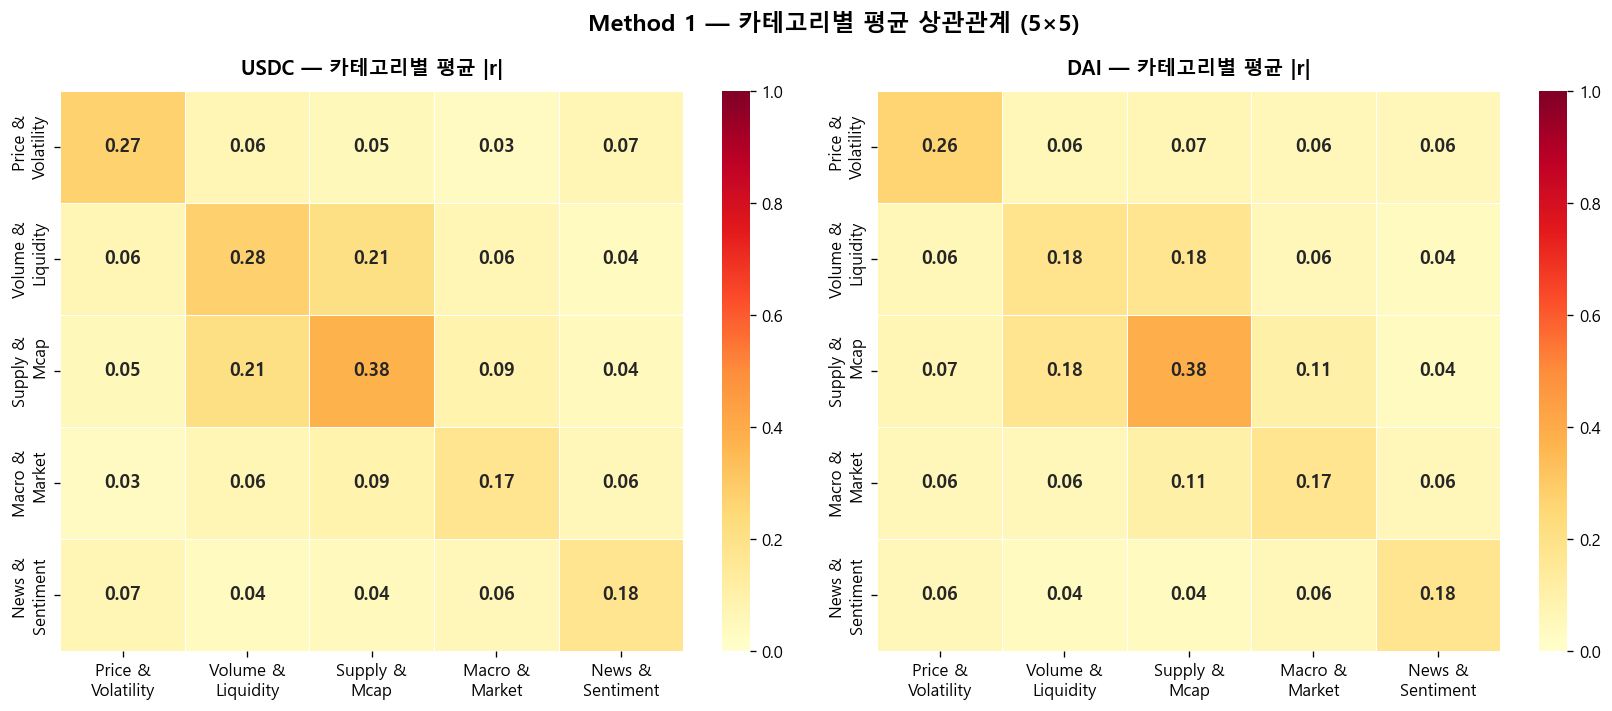

In [9]:
def get_category_map(df, coin):
    """데이터프레임에 실제 존재하는 컬럼만 포함한 카테고리 맵 반환"""
    raw = {
        'Price &\nVolatility': [
            f'return_1d_{coin}', f'return_3d_{coin}', f'return_7d_{coin}',
            f'vol_7d_{coin}', f'vol_30d_{coin}', f'rsi_14_{coin}',
            f'ma7_dev_{coin}', f'ma30_dev_{coin}', f'high_low_spread_{coin}',
            f'upper_shadow_{coin}', f'lower_shadow_{coin}', f'drawdown_{coin}',
        ],
        'Volume &\nLiquidity': [
            f'volume_{coin}', f'volume_ratio_{coin}', f'turnover_rate_{coin}',
            f'inflow_{coin}', f'netflow_{coin}', f'volume_shock_{coin}',
            f'volume_z_{coin}', f'real_liquidity_shock_{coin}',
        ],
        'Supply &\nMcap': [
            f'supply_change_{coin}', f'mcap_change_1d_{coin}',
            f'mint_intensity_{coin}', f'circulating_ratio_{coin}',
            f'supply_growth_rate_{coin}', f'market_cap_{coin}',
        ],
        'Macro &\nMarket': [
            'vix', 'dxy', 'federal_funds_rate',
            'btc_return_1d', 'eth_return_1d',
            'crypto_stress', 'risk_off', 'fgi',
        ],
        'News &\nSentiment': [
            'news_sentiment_mean', 'news_positive_ratio',
            'news_negative_ratio', 'news_count',
            'news_sentiment_mean_lag7',
        ],
    }
    return {cat: [c for c in cols if c in df.columns]
            for cat, cols in raw.items()}


def category_corr_matrix(df, cat_map):
    """카테고리 간 평균 |Pearson r| 로 이루어진 5×5 행렬 반환"""
    cats = list(cat_map.keys())
    mat  = pd.DataFrame(index=cats, columns=cats, dtype=float)
    for c1 in cats:
        for c2 in cats:
            pairs = []
            for a in cat_map[c1]:
                for b in cat_map[c2]:
                    if a != b:
                        sub = df[[a, b]].dropna()
                        if len(sub) > 10:
                            pairs.append(abs(sub.corr().iloc[0, 1]))
            mat.loc[c1, c2] = np.mean(pairs) if pairs else 0.0
    return mat.astype(float)


# ── Method 1: 5×5 카테고리 히트맵 ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, coin in zip(axes, COINS):
    df      = dfs[coin]
    cat_map = get_category_map(df, coin)
    mat     = category_corr_matrix(df, cat_map)
    sns.heatmap(mat, ax=ax, annot=True, fmt='.2f', cmap='YlOrRd',
                vmin=0, vmax=1, linewidths=0.5,
                annot_kws={'size': 11, 'weight': 'bold'})
    ax.set_title(f'{coin} — 카테고리별 평균 |r|',
                 fontsize=12, fontweight='bold', pad=10)
plt.suptitle('Method 1 — 카테고리별 평균 상관관계 (5×5)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'eda_07a_category_corr.png', bbox_inches='tight')
plt.show()


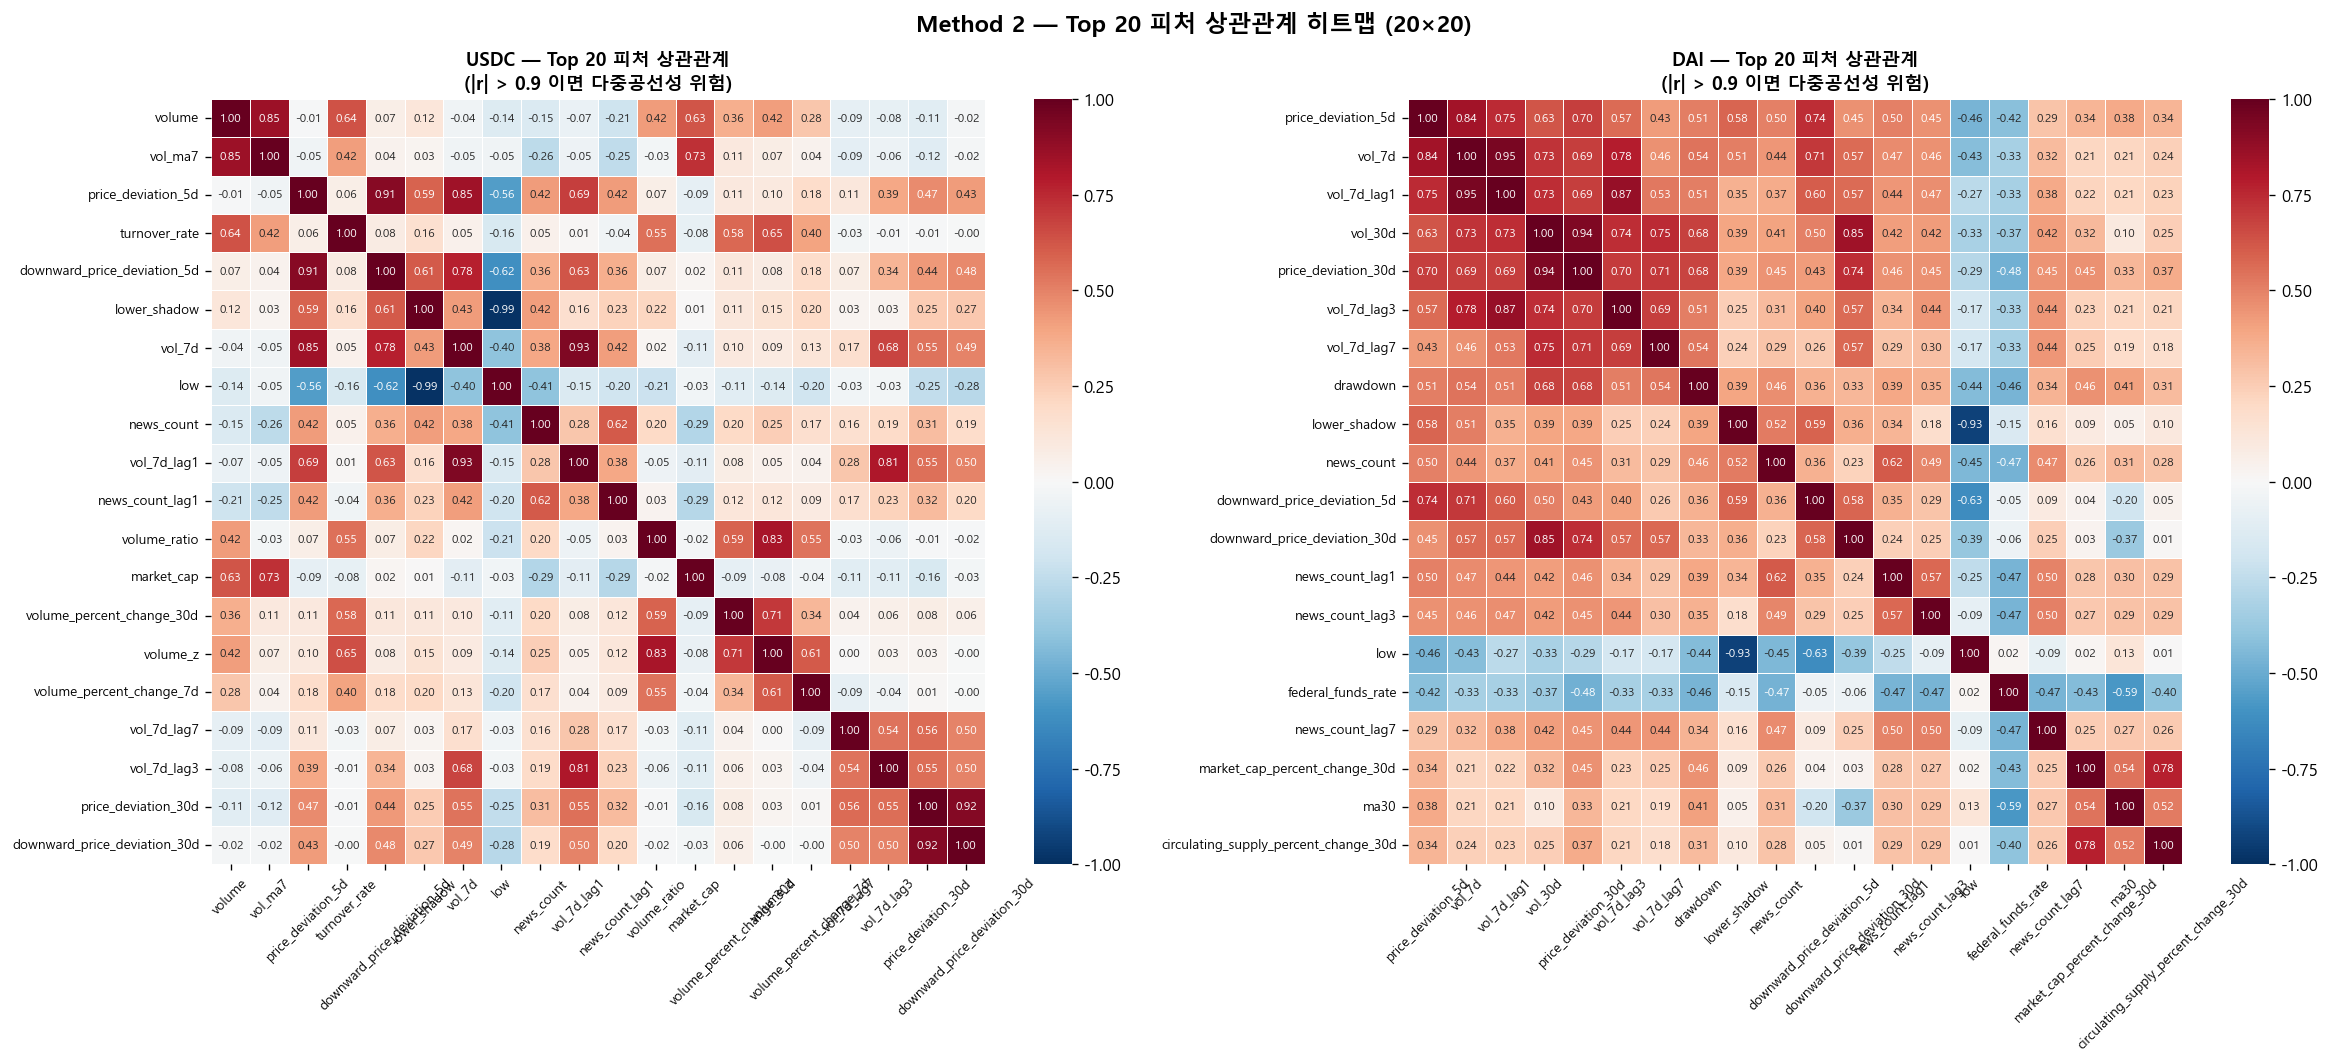

In [10]:
# ── Method 2: Top 20 피처 상관 히트맵 (20×20) ─────────────────────────────
from scipy.stats import pointbiserialr

def top20_by_pb(df, coin):
    """Point-Biserial |r| 기준 상위 20개 피처 이름 반환"""
    num_cols  = df.select_dtypes(include=[np.number]).columns.tolist()
    excl_kw   = ['depeg', 'thresh', 'V_monthly', 'ThreshD', 'ThreshU']
    feat_cols = [c for c in num_cols if not any(k in c for k in excl_kw)]
    scores = {}
    for col in feat_cols:
        valid = df[[col, 'depeg']].dropna()
        if len(valid) > 30 and valid[col].std() > 0:
            r, _ = pointbiserialr(valid['depeg'], valid[col])
            scores[col] = abs(r)
    return sorted(scores, key=scores.get, reverse=True)[:20]


fig, axes = plt.subplots(1, 2, figsize=(20, 9))
for ax, coin in zip(axes, COINS):
    df    = dfs[coin]
    top20 = top20_by_pb(df, coin)
    corr  = df[top20].corr()
    labels = [c.replace(f'_{coin}', '') for c in top20]
    sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='RdBu_r',
                vmin=-1, vmax=1, center=0, linewidths=0.3,
                xticklabels=labels, yticklabels=labels,
                annot_kws={'size': 7})
    ax.set_title(f'{coin} — Top 20 피처 상관관계\n(|r| > 0.9 이면 다중공선성 위험)',
                 fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.suptitle('Method 2 — Top 20 피처 상관관계 히트맵 (20×20)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'eda_07b_top20_corr.png', bbox_inches='tight')
plt.show()


---
## 8. Event Study — 디페깅 전후 변수 평균 추이

**Event Study란?**
- 디페깅 발생일(t=0) 전후 N일 동안 변수의 평균이 어떻게 변하는지 추적
- 패턴이 뚜렷하면 → 해당 변수가 디페깅의 **선행 신호**로 활용 가능

**확인 목적:**
- 디페깅 전에 어떤 변수가 먼저 반응하는지 파악 (조기 경보 근거)
- VIX, DXY 등 거시 변수의 선행성 확인


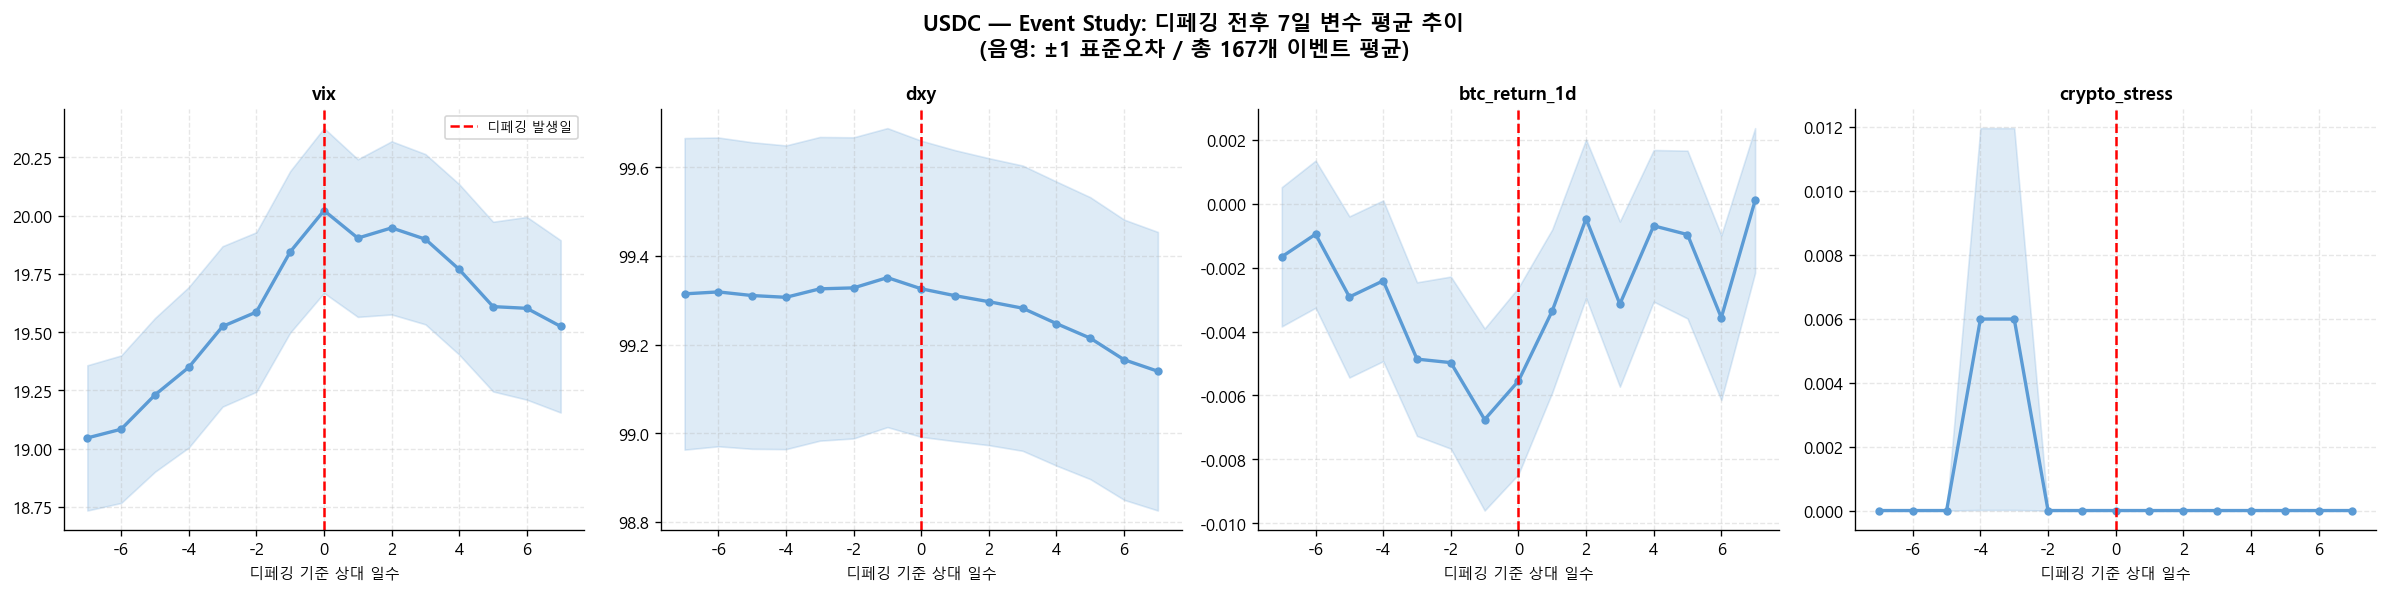

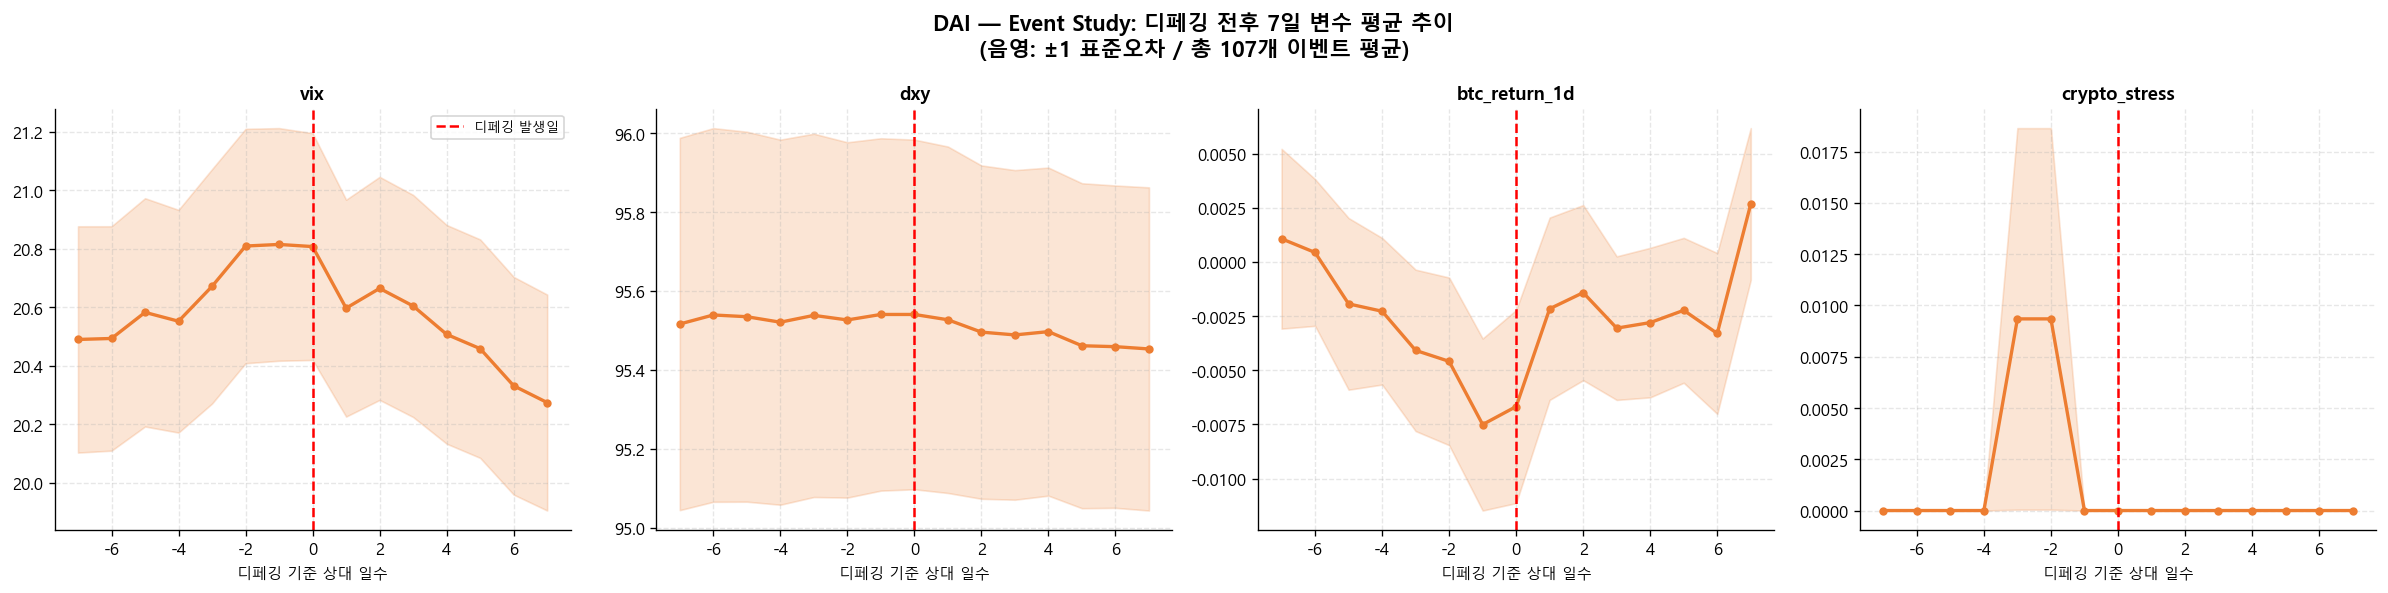

In [11]:
EVENT_FEATURES = ['vix', 'dxy', 'btc_return_1d', 'crypto_stress']
WINDOW = 7  # 이벤트 전후 7일씩

for coin in COINS:
    df = dfs[coin].copy().reset_index(drop=True)

    # 앞뒤로 WINDOW일 여유가 있는 디페깅 발생일 인덱스만 추출
    depeg_idx = [i for i in df.index[df['depeg'] == 1].tolist()
                 if i >= WINDOW and i <= len(df) - WINDOW - 1]

    # 실제 존재하는 피처만 선택 (코인별 / 공통 피처 순서로 시도)
    plot_feats = []
    for f in EVENT_FEATURES:
        col = f'{f}_{coin}' if f'{f}_{coin}' in df.columns else f
        if col in df.columns:
            plot_feats.append((f, col))

    fig, axes = plt.subplots(1, len(plot_feats), figsize=(5 * len(plot_feats), 5))
    if len(plot_feats) == 1:
        axes = [axes]

    for ax, (label, col) in zip(axes, plot_feats):
        # 각 이벤트 주변 WINDOW일 데이터 수집 → 평균 계산
        windows = [df.loc[i - WINDOW: i + WINDOW, col].values
                   for i in depeg_idx]
        windows = [w for w in windows if len(w) == 2 * WINDOW + 1]

        if not windows:
            ax.set_visible(False)
            continue

        arr  = np.array(windows)  # shape: (n_events, 2*WINDOW+1)
        mean = arr.mean(axis=0)
        se   = arr.std(axis=0) / np.sqrt(len(arr))  # 표준오차 (불확실성 범위)
        x    = np.arange(-WINDOW, WINDOW + 1)        # -7 ~ +7

        ax.plot(x, mean, color=COIN_COLORS[coin], linewidth=2,
                marker='o', markersize=4)
        # 음영: 평균 ± 표준오차 범위 표시
        ax.fill_between(x, mean - se, mean + se,
                        alpha=0.2, color=COIN_COLORS[coin])
        ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='디페깅 발생일')
        ax.set_title(f'{label}', fontsize=11, fontweight='bold')
        ax.set_xlabel('디페깅 기준 상대 일수', fontsize=9)
        ax.grid(alpha=0.3, linestyle='--')
        ax.spines[['top', 'right']].set_visible(False)
        if ax == axes[0]:
            ax.legend(fontsize=8)

    plt.suptitle(
        f'{coin} — Event Study: 디페깅 전후 {WINDOW}일 변수 평균 추이\n'
        f'(음영: ±1 표준오차 / 총 {len(depeg_idx)}개 이벤트 평균)',
        fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'eda_08_event_study_{coin.lower()}.png', bbox_inches='tight')
    plt.show()


---
## 9. USDC vs DAI 비교 분석

**확인 목적:**
- 두 코인이 같은 날 동시에 디페깅되는 경우 vs 독립적으로 발생하는 경우 비교
- 시장 충격(VIX 상위, BTC 급락) 환경에서 두 코인의 반응 강도 차이 확인
- USDC(중앙화)와 DAI(분산화 알고리즘)의 구조적 행동 차이 파악


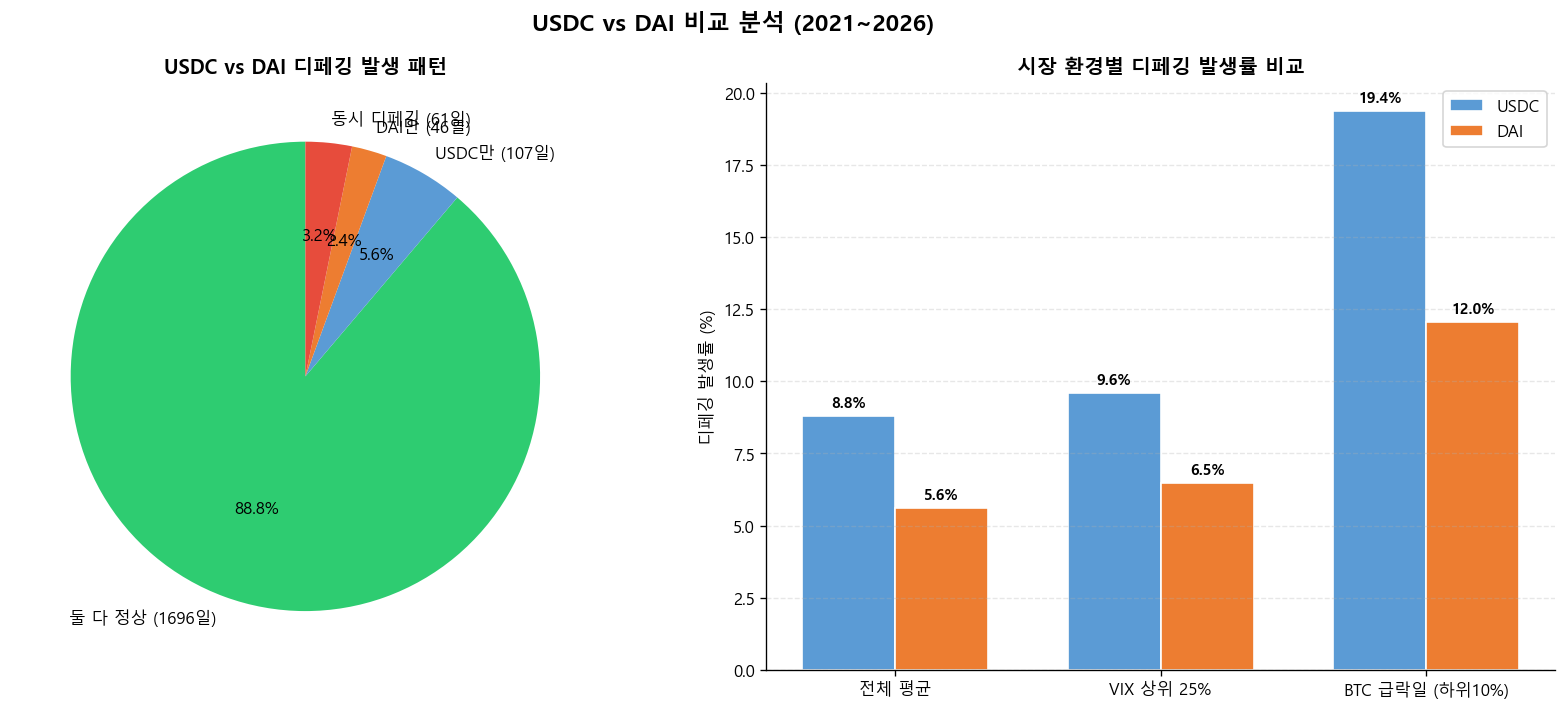

동시 디페깅:   61일 (3.2%)
USDC만 디페깅: 107일
DAI만 디페깅:  46일
둘 다 정상:    1696일


In [12]:
df_usdc = dfs['USDC']
df_dai  = dfs['DAI']

# 날짜 기준으로 두 데이터프레임 병합
merged = pd.merge(
    df_usdc[['Date', 'depeg']].rename(columns={'depeg': 'dep_usdc'}),
    df_dai[['Date',  'depeg']].rename(columns={'depeg': 'dep_dai'}),
    on='Date', how='inner'
)

# 동시 디페깅 패턴 분류
both    = ((merged['dep_usdc'] == 1) & (merged['dep_dai'] == 1)).sum()
only_u  = ((merged['dep_usdc'] == 1) & (merged['dep_dai'] == 0)).sum()
only_d  = ((merged['dep_usdc'] == 0) & (merged['dep_dai'] == 1)).sum()
neither = ((merged['dep_usdc'] == 0) & (merged['dep_dai'] == 0)).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── 차트 1: 파이 차트 — 동시/단독 디페깅 분류 ────────────────────────────
ax1 = axes[0]
labels_pie = [
    f'둘 다 정상 ({neither}일)',
    f'USDC만 ({only_u}일)',
    f'DAI만 ({only_d}일)',
    f'동시 디페깅 ({both}일)',
]
ax1.pie([neither, only_u, only_d, both],
        labels=labels_pie,
        colors=['#2ECC71', '#5B9BD5', '#ED7D31', '#E74C3C'],
        autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 10})
ax1.set_title('USDC vs DAI 디페깅 발생 패턴',
              fontsize=12, fontweight='bold')

# ── 차트 2: 시장 환경별 디페깅 발생률 비교 ────────────────────────────────
ax2 = axes[1]
compare_items = [('전체 평균', df_usdc['depeg'].mean()*100, df_dai['depeg'].mean()*100)]

# VIX 상위 25% (공포 구간) 에서의 디페깅 비율
if 'vix' in df_usdc.columns:
    vix_hi = df_usdc['vix'].quantile(0.75)
    compare_items.append((
        'VIX 상위 25%',
        df_usdc[df_usdc['vix'] >= vix_hi]['depeg'].mean() * 100,
        df_dai[df_dai['vix']   >= vix_hi]['depeg'].mean() * 100,
    ))

# BTC 급락일 (하위 10%) 에서의 디페깅 비율
if 'btc_return_1d' in df_usdc.columns:
    btc_lo = df_usdc['btc_return_1d'].quantile(0.10)
    compare_items.append((
        'BTC 급락일 (하위10%)',
        df_usdc[df_usdc['btc_return_1d'] <= btc_lo]['depeg'].mean() * 100,
        df_dai[df_dai['btc_return_1d']   <= btc_lo]['depeg'].mean() * 100,
    ))

x = np.arange(len(compare_items))
w = 0.35
usdc_vals = [v[1] for v in compare_items]
dai_vals  = [v[2] for v in compare_items]

ax2.bar(x - w/2, usdc_vals, width=w, label='USDC', color='#5B9BD5', edgecolor='white')
ax2.bar(x + w/2, dai_vals,  width=w, label='DAI',  color='#ED7D31', edgecolor='white')

for xi, (u, d) in zip(x, zip(usdc_vals, dai_vals)):
    ax2.text(xi - w/2, u + 0.3, f'{u:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax2.text(xi + w/2, d + 0.3, f'{d:.1f}%', ha='center', fontsize=9, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels([v[0] for v in compare_items], fontsize=10)
ax2.set_ylabel('디페깅 발생률 (%)', fontsize=10)
ax2.set_title('시장 환경별 디페깅 발생률 비교', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.spines[['top', 'right']].set_visible(False)

plt.suptitle('USDC vs DAI 비교 분석 (2021~2026)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'eda_09_usdc_vs_dai.png', bbox_inches='tight')
plt.show()

print(f'동시 디페깅:   {both}일 ({both/len(merged)*100:.1f}%)')
print(f'USDC만 디페깅: {only_u}일')
print(f'DAI만 디페깅:  {only_d}일')
print(f'둘 다 정상:    {neither}일')
